Generating detailed chromosome plot...


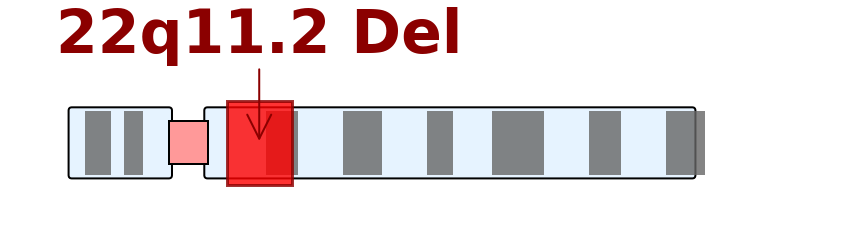

In [40]:
def plot_detailed_chromosome_22():
    """
    More detailed version with closer representation of actual Chromosome 22 banding
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 4), facecolor='none')
    fig.patch.set_alpha(0.0)
    ax.set_facecolor('none')
    
    # Chromosome 22 is acrocentric (centromere near one end)
    chr_length = 10
    chr_width = 1.0
    
    # Chromosome 22 specific proportions (acrocentric)
    p_arm_length = 1.5  # Short arm
    q_arm_length = 7.5  # Long arm
    centromere_width = 0.6
    
    x_start = 1
    y_center = 2
    
    # Draw p arm (short arm)
    p_arm = FancyBboxPatch(
        (x_start, y_center - chr_width/2), 
        p_arm_length, chr_width,
        boxstyle="round,pad=0.05",
        facecolor='#E6F3FF',
        edgecolor='black',
        linewidth=2
    )
    ax.add_patch(p_arm)
    
    # Draw q arm (long arm)
    q_arm = FancyBboxPatch(
        (x_start + p_arm_length + centromere_width, y_center - chr_width/2), 
        q_arm_length, chr_width,
        boxstyle="round,pad=0.05",
        facecolor='#E6F3FF',
        edgecolor='black',
        linewidth=2
    )
    ax.add_patch(q_arm)
    
    # Draw centromere
    centromere = Rectangle(
        (x_start + p_arm_length, y_center - chr_width/3), 
        centromere_width, 2*chr_width/3,
        facecolor='#FF9999',
        edgecolor='black',
        linewidth=2
    )
    ax.add_patch(centromere)
    
    # Add detailed banding pattern for Chromosome 22
    # G-bands (dark bands)
    g_bands = [
        (x_start + 0.2, 0.4),  # p11.2
        (x_start + 0.8, 0.3),  # p11.1
        (x_start + 3.0, 0.5),  # q11.1-q11.21
        (x_start + 4.2, 0.6),  # q11.23
        (x_start + 5.5, 0.4),  # q12.1
        (x_start + 6.5, 0.8),  # q12.3-q13.1
        (x_start + 8.0, 0.5),  # q13.2
        (x_start + 9.2, 0.6),  # q13.31-q13.33
    ]
    
    for x_pos, band_width in g_bands:
        band = Rectangle(
            (x_pos, y_center - chr_width/2), 
            band_width, chr_width,
            facecolor='#666666',
            edgecolor='none',
            alpha=0.8
        )
        ax.add_patch(band)
    
    # Highlight 22q11.2 deletion region (more precise location)
    # 22q11.2 is located in the proximal long arm, near the centromere
    deletion_start = x_start + p_arm_length + centromere_width + 0.3
    deletion_width = 1.0  # Represents ~3Mb deletion
    
    deletion_region = Rectangle(
        (deletion_start, y_center - chr_width/2 - 0.15), 
        deletion_width, chr_width + 0.3,
        facecolor='red',
        edgecolor='darkred',
        linewidth=3,
        alpha=0.8
    )
    ax.add_patch(deletion_region)
    
    # Add deletion label with arrow
    ax.annotate('22q11.2 Del', 
                xy=(deletion_start + deletion_width/2, y_center),
                xytext=(deletion_start + deletion_width/2, y_center + 1.2),
                ha='center', va='bottom',
                fontsize=60, fontweight='bold', color='darkred',
                arrowprops=dict(arrowstyle='->', color='darkred', lw=2))
    
    # Add size annotation
    #ax.text(deletion_start + deletion_width/2, y_center - 1.0, 
    #        '~3 Mb deletion', 
   #         ha='center', va='center', fontsize=9, style='italic', color='darkred')
    
    # Add chromosome label
    #ax.text(x_start + (p_arm_length + centromere_width + q_arm_length)/2, 
    #        y_center - 1.5, 'Chromosome 22', 
    #        ha='center', va='center', fontsize=18, fontweight='bold')
    
    # Add scale indicator
    #ax.text(x_start + chr_length + 0.5, y_center, 
    #        f'{chr_length*5} Mb', 
   #         ha='left', va='center', fontsize=10, style='italic')
    
    # Set axis properties
    ax.set_xlim(0, 13)
    ax.set_ylim(0.5, 3.5)
    ax.set_aspect('equal')
    ax.axis('off')
    
    plt.tight_layout()
    return fig, ax

print("Generating detailed chromosome plot...")
fig2, ax2 = plot_detailed_chromosome_22()
plt.show()

Creating detailed gene mutation plot with mutation types...


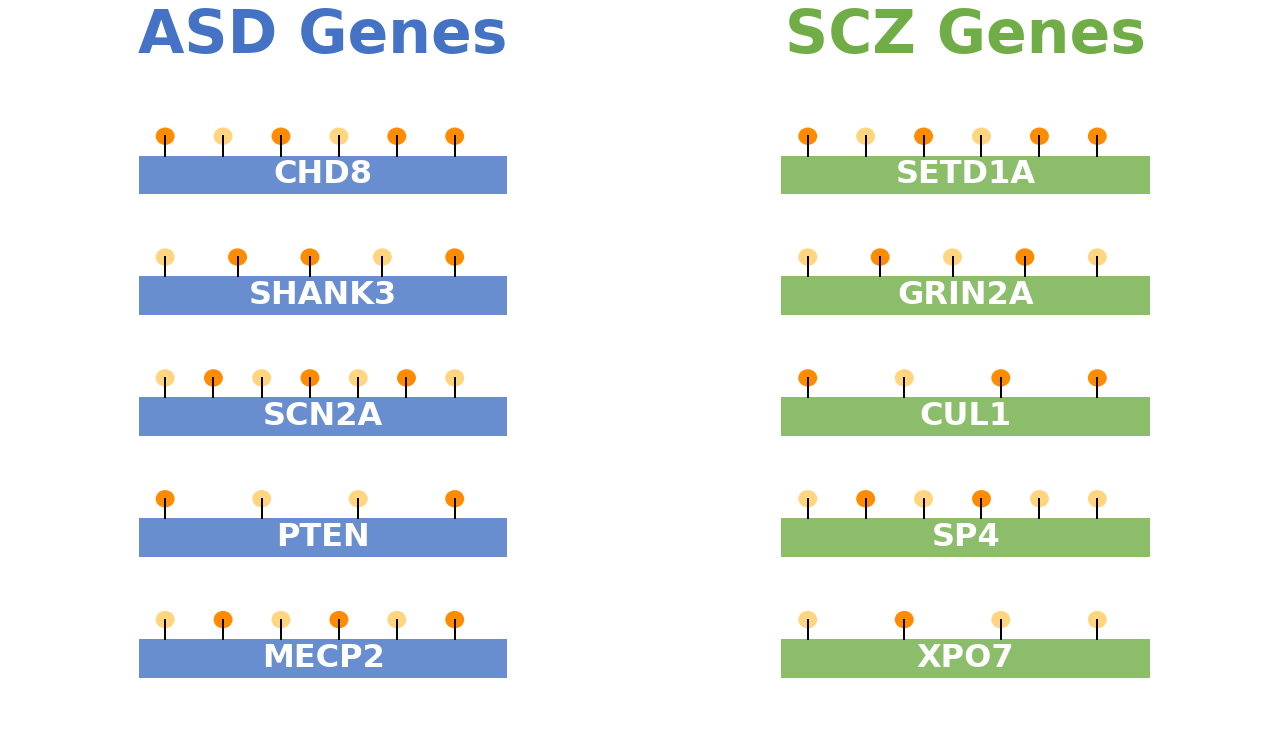

In [41]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
import numpy as np

def create_gene_mutation_plot():
    """
    Create a plot showing ASD and SCZ genes with mutations
    Blue for ASD genes, Green for SCZ genes
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))
    
    # Gene data: (gene_name, num_mutations, associated_region)
    asd_genes = [
        ("CHD8", 6, "14q11.2"), 
        ("SHANK3", 5, "22q13.33"),
        ("GRIA1", 5, "5q33.2"),
        ("SCN2A", 7, "2q24.3"),
        ("PTEN", 4, "10q23.31")
    ]
    
    scz_genes = [
        ("CHD8", 6, "14q11.2"),
        ("SHANK3", 5, "22q13.33"), 
        ("GRIA1", 5, "5q33.2"),
        ("DISC1", 6, "1q42.2"),
        ("CACNA1C", 8, "12p13.33")
    ]
    

# Enhanced version with more details
def create_detailed_gene_mutation_plot():
    """
    Enhanced version with mutation types and more realistic data.
    Mutation types are mixed for each gene (not all LGD then all Dmis).
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 12))
    
    # For each gene, specify a list of mutation types in the order they appear (mixed)
    asd_genes = [
        ("CHD8",    ['LGD', 'Dmis', 'LGD', 'Dmis', 'LGD', 'LGD']), 
        ("SHANK3",  ['Dmis', 'LGD', 'LGD', 'Dmis', 'LGD']),
        ("SCN2A",   ['Dmis', 'LGD', 'Dmis', 'LGD', 'Dmis', 'LGD', 'Dmis']),
        ("PTEN",    ['LGD', 'Dmis', 'Dmis', 'LGD']),
        ("MECP2",   ['Dmis', 'LGD', 'Dmis', 'LGD', 'Dmis', 'LGD'])
    ]
    
    scz_genes = [
        ("SETD1A",  ['LGD', 'Dmis', 'LGD', 'Dmis', 'LGD', 'LGD']),
        ("GRIN2A",  ['Dmis', 'LGD', 'Dmis', 'LGD', 'Dmis']),
        ("CUL1",    ['LGD', 'Dmis', 'LGD', 'LGD']),
        ("SP4",     ['Dmis', 'LGD', 'Dmis', 'LGD', 'Dmis', 'Dmis']),
        ("XPO7",    ['Dmis', 'LGD', 'Dmis', 'Dmis'])
    ]
    
    # Mutation type colors - only LGD and Dmis
    mutation_colors = {
        'LGD': '#FF8C00',     # Dark orange for Likely Gene Disrupting
        'Dmis': '#FFD580'     # Light orange for Damaging Missense
    }
    
    def plot_detailed_genes(ax, genes, gene_color, title):
        """Plot genes with colored mutation types, mixing LGD and Dmis for each gene"""
        ax.set_xlim(0, 12)
        ax.set_ylim(0, len(genes) * 2.5 + 1)
        
        # Shorten the stick length by reducing the vertical distance
        stick_start_offset = 0.4
        stick_end_offset = 0.8  # was 1.5, now much shorter

        for i, (gene_name, mutation_types) in enumerate(genes):
            y_pos = (len(genes) - i - 1) * 2.5 + 1.5
            
            # Draw gene rectangle (no black border)
            gene_rect = Rectangle(
                (2.5, y_pos - 0.4), 7, 0.8,
                facecolor=gene_color,
                edgecolor='none',
                linewidth=0,
                alpha=0.8
            )
            ax.add_patch(gene_rect)
            
            # Add gene name (double the font size from 16 to 32)
            ax.text(6, y_pos, gene_name, ha='center', va='center', 
                   fontsize=32, fontweight='bold', color='white')
            
            # Calculate total mutations and positions
            total_mutations = len(mutation_types)
            mutation_positions = np.linspace(3, 8.5, total_mutations)
            
            # Add mutations with different colors, mixing types
            for pos_idx, mut_type in enumerate(mutation_types):
                x_pos = mutation_positions[pos_idx]
                
                # Draw lollipop stick (shorter)
                ax.plot([x_pos, x_pos], [y_pos + stick_start_offset, y_pos + stick_end_offset], 
                       'k-', linewidth=2)
                
                # Draw colored mutation head (move closer to gene, no black border)
                mutation_circle = Circle(
                    (x_pos, y_pos + stick_end_offset), 0.18,
                    facecolor=mutation_colors[mut_type],
                    edgecolor='none',
                    linewidth=0
                )
                ax.add_patch(mutation_circle)
        
        # Add title
        ax.set_title(title, color=gene_color, fontsize=60, fontweight='bold', pad=25)
        ax.axis('off')
        
        return ax
    
    # Plot both disorders
    plot_detailed_genes(ax1, asd_genes, '#4472C4', 'ASD Genes')
    plot_detailed_genes(ax2, scz_genes, '#70AD47', 'SCZ Genes')
    
    # Add legend for mutation types (only LGD and Dmis)
    #legend_elements = [plt.Circle((0,0), 0.1, facecolor=color, edgecolor='black', label=mut_type) 
   #                   for mut_type, color in mutation_colors.items()]
    
    #fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.02), 
    #          ncol=2, fontsize=14, title='Mutation Types', title_fontsize=16)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    return fig


print("Creating detailed gene mutation plot with mutation types...")
fig2 = create_detailed_gene_mutation_plot()
plt.show()

# Optional: Save figures
# fig1.savefig('gene_mutations_basic.png', dpi=300, bbox_inches='tight')
# fig2.savefig('gene_mutations_detailed.png', dpi=300, bbox_inches='tight')

Creating detailed gene mutation plot with 3 genes + 3 dots for each disorder...


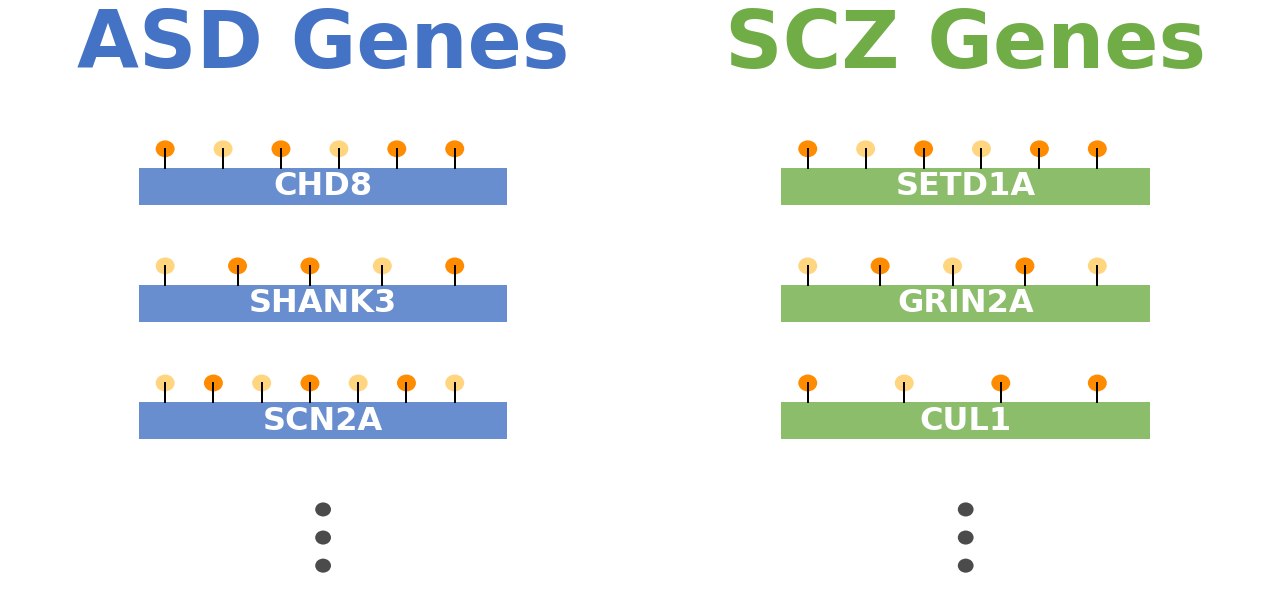

In [66]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Circle
import numpy as np

def create_detailed_gene_mutation_plot():
    """
    Plot showing 3 named genes for ASD and SCZ, then 3 dots to indicate more genes (total 5 per disorder).
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

    # Only 3 named genes for each disorder
    asd_genes = [
        ("CHD8",    ['LGD', 'Dmis', 'LGD', 'Dmis', 'LGD', 'LGD']), 
        ("SHANK3",  ['Dmis', 'LGD', 'LGD', 'Dmis', 'LGD']),
        ("SCN2A",   ['Dmis', 'LGD', 'Dmis', 'LGD', 'Dmis', 'LGD', 'Dmis']),
    ]
    scz_genes = [
        ("SETD1A",  ['LGD', 'Dmis', 'LGD', 'Dmis', 'LGD', 'LGD']),
        ("GRIN2A",  ['Dmis', 'LGD', 'Dmis', 'LGD', 'Dmis']),
        ("CUL1",    ['LGD', 'Dmis', 'LGD', 'LGD']),
    ]

    # Mutation type colors - only LGD and Dmis
    mutation_colors = {
        'LGD': '#FF8C00',     # Dark orange for Likely Gene Disrupting
        'Dmis': '#FFD580'     # Light orange for Damaging Missense
    }

    def plot_detailed_genes(ax, genes, gene_color, title):
        """Plot 3 genes, then 3 dots to indicate more genes (total 5 per disorder)"""
        n_genes = 3
        n_dots = 3
        total_rows = n_genes + 1  # 3 genes + 1 row for dots

        ax.set_xlim(0, 12)
        ax.set_ylim(0, total_rows * 2.5 + 1)

        stick_start_offset = 0.4
        stick_end_offset = 0.8

        # Plot the 3 named genes
        for i, (gene_name, mutation_types) in enumerate(genes):
            y_pos = (total_rows - i - 1) * 2.5 + 1.5

            # Draw gene rectangle (no black border)
            gene_rect = Rectangle(
                (2.5, y_pos - 0.4), 7, 0.8,
                facecolor=gene_color,
                edgecolor='none',
                linewidth=0,
                alpha=0.8
            )
            ax.add_patch(gene_rect)

            # Add gene name
            ax.text(6, y_pos, gene_name, ha='center', va='center', 
                    fontsize=32, fontweight='bold', color='white')

            # Calculate total mutations and positions
            total_mutations = len(mutation_types)
            mutation_positions = np.linspace(3, 8.5, total_mutations)

            # Add mutations with different colors, mixing types
            for pos_idx, mut_type in enumerate(mutation_types):
                x_pos = mutation_positions[pos_idx]
                ax.plot([x_pos, x_pos], [y_pos + stick_start_offset, y_pos + stick_end_offset], 
                        'k-', linewidth=2)
                mutation_circle = Circle(
                    (x_pos, y_pos + stick_end_offset), 0.18,
                    facecolor=mutation_colors[mut_type],
                    edgecolor='none',
                    linewidth=0
                )
                ax.add_patch(mutation_circle)

        # Add 3 dots to indicate more genes (centered below the last gene)
        dots_x = 6  # x position for vertical dots (centered below the last gene)
        dots_y = np.linspace(0.9, 2.1, n_dots)  # vertical positions for the dots
        for y in dots_y:
            dot = Circle((dots_x, y), 0.15, facecolor='black', edgecolor='none', alpha=0.7)
            ax.add_patch(dot)

        # Optionally, add a faint label for the dots
        #ax.text(8.5, dots_y, "more genes", va='center', ha='left', fontsize=18, color='gray', alpha=0.7)

        # Add title
        ax.set_title(title, color=gene_color, fontsize=80, fontweight='bold', pad=25)
        ax.axis('off')
        return ax

    # Plot both disorders
    plot_detailed_genes(ax1, asd_genes, '#4472C4', 'ASD Genes')
    plot_detailed_genes(ax2, scz_genes, '#70AD47', 'SCZ Genes')

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    return fig

print("Creating detailed gene mutation plot with 3 genes + 3 dots for each disorder...")
fig2 = create_detailed_gene_mutation_plot()
plt.show()

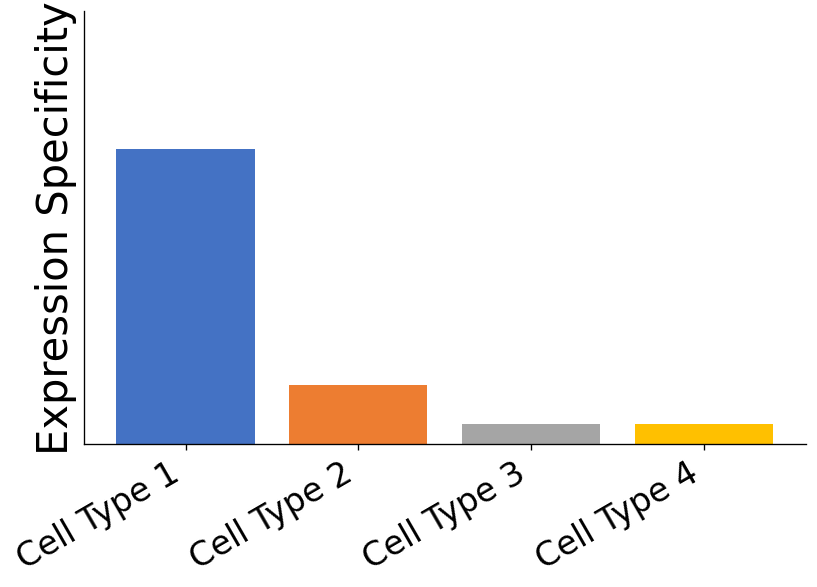

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Example data: gene expression specificity for 4 cell types
gene_name = "GENE1"
cell_types = ["Cell Type 1", "Cell Type 2", "Cell Type 3", "Cell Type 4"]
specificity = [0.75, 0.15, 0.05, 0.05]  # Example: sum to 1

fig, ax = plt.subplots(figsize=(7, 5), dpi=120, facecolor='none')
fig.patch.set_alpha(0.0)

bars = ax.bar(cell_types, specificity, color=["#4472C4", "#ED7D31", "#A5A5A5", "#FFC000"], edgecolor='none')

# # Annotate bars with values (font size x3: 13*3=39)
# for bar, val in zip(bars, specificity):
#     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.2f}", 
#             ha='center', va='bottom', fontsize=39)

ax.set_ylim(0, 1.1)
ax.set_ylabel("Expression Specificity", fontsize=25)  # 15*3=45
#ax.set_xlabel("Cell Type", fontsize=45)               # 15*3=45

# Set tick label font sizes (default is 10, so 10*3=30)
ax.tick_params(axis='x', labelsize=20)
# Rotate x-axis labels for better fit
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# Remove y ticks
ax.set_yticks([])

# Remove upper and right border
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
# Show with transparent background in notebook

plt.show()


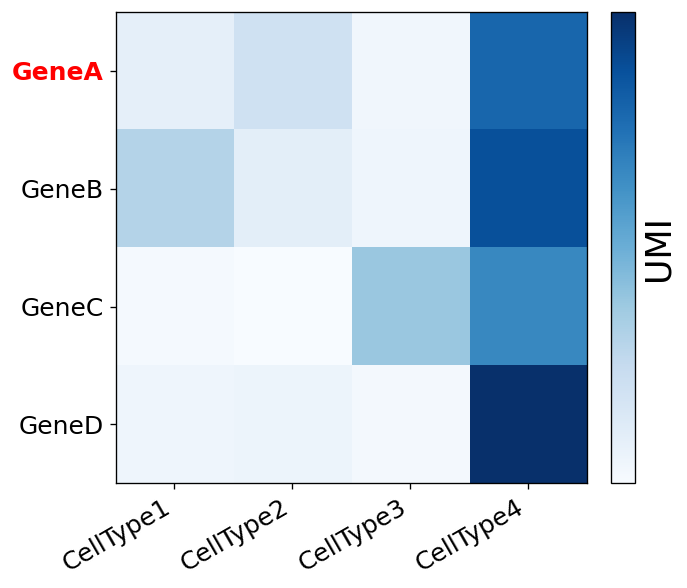

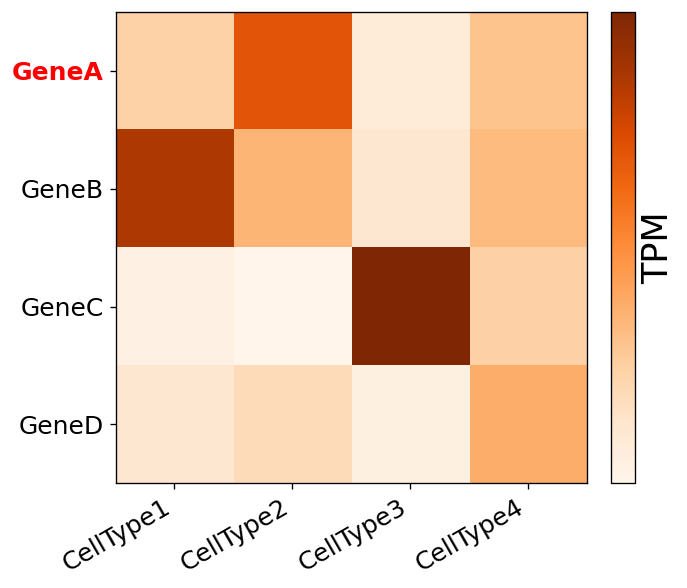

In [103]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Example: 4 genes x 4 cell types
genes = ["GeneA", "GeneB", "GeneC", "GeneD"]
cell_types = ["CellType1", "CellType2", "CellType3", "CellType4"]

# Simulate raw UMI counts (integers, e.g., from scRNA-seq)
# Make CellType4 (last column) have high expression for all genes
np.random.seed(42)
lam = [
    [100, 200, 50, 800],   # GeneA: high in CellType4
    [300, 120, 60, 900],   # GeneB: high in CellType4
    [20,  10, 400, 700],   # GeneC: high in CellType4
    [50,  60, 30, 1000],   # GeneD: high in CellType4
]
raw_umi = np.random.poisson(lam=lam, size=(4,4))

# Calculate TPM
# 1. For each cell type (column), sum UMI counts
umi_sums = raw_umi.sum(axis=0, keepdims=True)
# 2. TPM = (UMI / sum_UMI) * 1e6 for each cell type
tpm = (raw_umi / umi_sums) * 1e6

# Font size scaling factor
fs = 1.5

# Plot: Raw UMI counts heatmap (separate figure)
fig_umi, ax_umi = plt.subplots(figsize=(6, 5), dpi=120)
im0 = ax_umi.imshow(raw_umi, cmap="Blues")
ax_umi.set_xticks(np.arange(len(cell_types)))
ax_umi.set_yticks(np.arange(len(genes)))

# Make GeneA (first ytick) red and bold using fontproperties
yticklabels_umi = []
for i, g in enumerate(genes):
    if i == 0:
        yticklabels_umi.append(g)
    else:
        yticklabels_umi.append(g)
ax_umi.set_xticklabels(cell_types, rotation=30, ha='right', fontsize=10*fs)
ax_umi.set_yticklabels(yticklabels_umi, fontsize=10*fs)
# Remove numbers inside each cell (do not annotate)
cbar_umi = fig_umi.colorbar(im0, ax=ax_umi, fraction=0.046, pad=0.04)
cbar_umi.set_ticks([])  # Hide colorbar numbers
cbar_umi.set_label("UMI", fontsize=14*fs)
ax_umi.tick_params(axis='both', which='major', labelsize=10*fs)
fig_umi.tight_layout()

# Set GeneA ytick label to red and bold
labels = ax_umi.get_yticklabels()
labels[0].set_color('red')
labels[0].set_fontweight('bold')
ax_umi.set_yticklabels(labels)

plt.show()

# Plot: TPM heatmap (separate figure)
fig_tpm, ax_tpm = plt.subplots(figsize=(6, 5), dpi=120)
im1 = ax_tpm.imshow(tpm, cmap="Oranges")
ax_tpm.set_xticks(np.arange(len(cell_types)))
ax_tpm.set_yticks(np.arange(len(genes)))

# Make GeneA (first ytick) red and bold using fontproperties
yticklabels_tpm = []
for i, g in enumerate(genes):
    if i == 0:
        yticklabels_tpm.append(g)
    else:
        yticklabels_tpm.append(g)
ax_tpm.set_xticklabels(cell_types, rotation=30, ha='right', fontsize=10*fs)
ax_tpm.set_yticklabels(yticklabels_tpm, fontsize=10*fs)
# Remove numbers inside each cell (do not annotate)
cbar_tpm = fig_tpm.colorbar(im1, ax=ax_tpm, fraction=0.046, pad=0.04)
cbar_tpm.set_ticks([])  # Hide colorbar numbers
cbar_tpm.set_label("TPM", fontsize=14*fs)
ax_tpm.tick_params(axis='both', which='major', labelsize=10*fs)
fig_tpm.tight_layout()

# Set GeneA ytick label to red and bold
labels = ax_tpm.get_yticklabels()
labels[0].set_color('red')
labels[0].set_fontweight('bold')
ax_tpm.set_yticklabels(labels)

plt.show()


In [87]:
tpm

array([[196721.31147541, 539845.75835476,  80614.20345489,
        114640.8839779 ],
       [653688.52459016, 280205.65552699, 105566.21880998,
         53867.40331492],
       [ 43032.78688525,  20565.55269923, 761996.16122841,
        124309.39226519],
       [106557.37704918, 159383.03341902,  51823.41650672,
        707182.32044199]])

: 

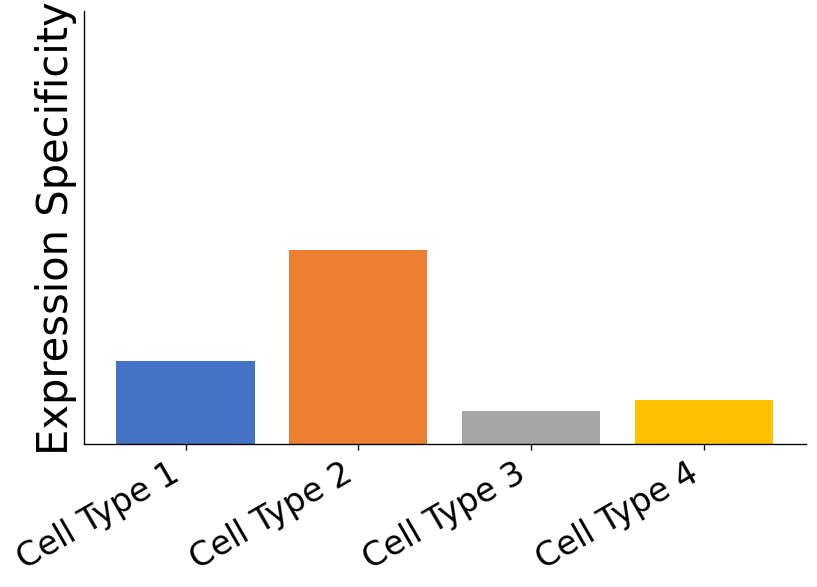

In [91]:
import matplotlib.pyplot as plt
import numpy as np

# Example data: gene expression specificity for 4 cell types
gene_name = "GENE1"
cell_types = ["Cell Type 1", "Cell Type 2", "Cell Type 3", "Cell Type 4"]
# calculate sepc from tpm
specificity = tpm / tpm.sum(axis=1)
specificity = specificity[0,:] # select first row

#specificity = [0.75, 0.15, 0.05, 0.05]  # Example: sum to 1

fig, ax = plt.subplots(figsize=(7, 5), dpi=120, facecolor='none')
fig.patch.set_alpha(0.0)
ax.set_facecolor('none')  # Set axes background to transparent

bars = ax.bar(cell_types, specificity, color=["#4472C4", "#ED7D31", "#A5A5A5", "#FFC000"], edgecolor='none')

# # Annotate bars with values (font size x3: 13*3=39)
# for bar, val in zip(bars, specificity):
#     ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.2f}", 
#             ha='center', va='bottom', fontsize=39)

ax.set_ylim(0, 1.1)
ax.set_ylabel("Expression Specificity", fontsize=25)  # 15*3=45
#ax.set_xlabel("Cell Type", fontsize=45)               # 15*3=45

# Set tick label font sizes (default is 10, so 10*3=30)
ax.tick_params(axis='x', labelsize=20)
# Rotate x-axis labels for better fit
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# Remove y ticks
ax.set_yticks([])

# Remove upper and right border
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.tight_layout()
# Show with transparent background in notebook

plt.show()


In [89]:
specificity

array([[0.21111465, 0.49376386, 0.08486564, 0.11185064],
       [0.7015164 , 0.25628696, 0.11113358, 0.05255633],
       [0.04618133, 0.01881005, 0.80218238, 0.12128383],
       [0.11435377, 0.1457779 , 0.05455648, 0.68997022]])